```markdown
# Chapter 2 – Neural Network Classification: Step-by-Step Code

This section will walk through the code implementation of a neural network for classification tasks, following the concepts outlined in the YouTube video.
```

In [1]:
# 1. Setup and Imports
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cpu


```markdown
## 60. Introduction to machine learning classification
## 61. Classification input and outputs
## 62. Architecture of a classification neural network
## 64. Turing our data into tensors

Let's generate a simple non-linear dataset using `make_circles` to illustrate classification. This will give us two concentric circles of data points, which a linear model cannot easily separate.
```

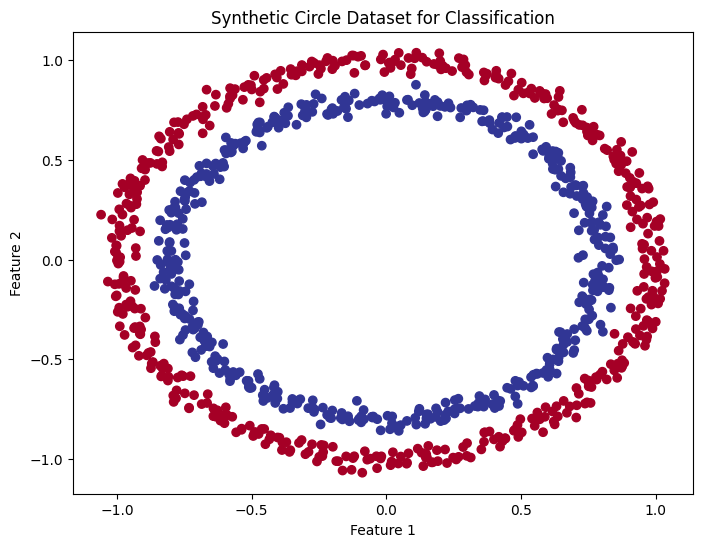

First 5 X samples:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 y samples:
[1 1 1 1 0]


In [2]:
# 2. Create a synthetic dataset for classification
# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples=n_samples,
                    noise=0.03,
                    random_state=42)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Synthetic Circle Dataset for Classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print(f"First 5 X samples:\n{X[:5]}")
print(f"First 5 y samples:\n{y[:5]}")

```markdown
## 64. Turing our data into tensors

Now, we'll convert our NumPy arrays into PyTorch tensors and split them into training and testing sets. This is crucial for working with PyTorch models.
```

In [3]:
# 3. Data Preparation: Convert data to tensors and split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, # 20% for testing
                                                    random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: torch.Size([800, 2])
y_train shape: torch.Size([800])
X_test shape: torch.Size([200, 2])
y_test shape: torch.Size([200])


```markdown
## 66. Coding a neural network for classification data
## 68. Using `torch.nn.Sequential`

We'll define a simple neural network model using `torch.nn.Sequential`. This model will consist of a few linear layers and ReLU activation functions to learn the non-linear patterns in our data.
```

In [4]:
# 4. Model Definition
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # Activation function

    def forward(self, x):
        # Apply layers with ReLU in between
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

# Instantiate the model
model_0 = CircleModelV0()
print(model_0)

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


```markdown
## 69. Loss, optimizer and evaluation functions for classification

For binary classification, `BCEWithLogitsLoss` is a common choice as it combines `Sigmoid` and `Binary Cross Entropy` into one numerically stable function. We'll use `Adam` as our optimizer.
```

In [5]:
# 5. Loss Function and Optimizer
loss_fn = nn.BCEWithLogitsLoss() # For binary classification with logits output
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.01)

# Helper function for accuracy (not built-in to PyTorch)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

print(f"Loss function: {loss_fn}")
print(f"Optimizer: {optimizer}")

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


```markdown
## 70. From model logits to prediction probabilities to prediction labels

Before training, it's important to understand how to transform the raw outputs (logits) from our model into meaningful prediction probabilities and then into discrete class labels. For binary classification with `BCEWithLogitsLoss`, we typically use the sigmoid activation function to get probabilities and then a threshold (e.g., 0.5) to get labels.
```

In [6]:
# 6. From Logits to Prediction Labels

# Example of getting logits from our untrained model
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test)[:5].squeeze()
    y_pred_probs = torch.sigmoid(y_logits)
    y_pred_labels = torch.round(y_pred_probs)

print(f"Raw Logits (first 5 test samples):\n{y_logits}")
print(f"Prediction Probabilities (first 5 test samples):\n{y_pred_probs}")
print(f"Prediction Labels (first 5 test samples):\n{y_pred_labels}")
print(f"True Labels (first 5 test samples):\n{y_test[:5]}")

Raw Logits (first 5 test samples):
tensor([-0.0107, -0.0052, -0.0696,  0.0273, -0.1483])
Prediction Probabilities (first 5 test samples):
tensor([0.4973, 0.4987, 0.4826, 0.5068, 0.4630])
Prediction Labels (first 5 test samples):
tensor([0., 0., 0., 1., 0.])
True Labels (first 5 test samples):
tensor([1., 0., 1., 0., 1.])


```markdown
## 71. Train and test loops

Now we'll implement the training and testing loops. This involves iterating through the data, performing forward passes, calculating loss, backpropagating gradients, and updating model parameters.
```

In [7]:
# 7. Training and Testing Loop

epochs = 100

# Lists to store loss and accuracy values
train_loss_list = []
test_loss_list = []
train_acc_list = []
test_acc_list = []

# Training loop
for epoch in range(epochs):
    ### Training
    model_0.train() # Set model to training mode

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # Convert logits to prediction probabilities and then to labels

    # 2. Calculate loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backward pass
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval() # Set model to evaluation mode
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        train_loss_list.append(loss.item())
        test_loss_list.append(test_loss.item())
        train_acc_list.append(acc)
        test_acc_list.append(test_acc)
        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}%")


Epoch: 0 | Train Loss: 0.6973 Acc: 42.25% | Test Loss: 0.6971 Acc: 42.50%
Epoch: 10 | Train Loss: 0.6903 Acc: 53.12% | Test Loss: 0.6909 Acc: 52.50%
Epoch: 20 | Train Loss: 0.6825 Acc: 57.38% | Test Loss: 0.6827 Acc: 58.50%
Epoch: 30 | Train Loss: 0.6598 Acc: 85.62% | Test Loss: 0.6592 Acc: 87.50%
Epoch: 40 | Train Loss: 0.6113 Acc: 91.38% | Test Loss: 0.6131 Acc: 93.50%
Epoch: 50 | Train Loss: 0.5325 Acc: 95.75% | Test Loss: 0.5402 Acc: 95.50%
Epoch: 60 | Train Loss: 0.4206 Acc: 97.38% | Test Loss: 0.4388 Acc: 96.50%
Epoch: 70 | Train Loss: 0.2904 Acc: 99.62% | Test Loss: 0.3174 Acc: 98.00%
Epoch: 80 | Train Loss: 0.1792 Acc: 100.00% | Test Loss: 0.2073 Acc: 99.50%
Epoch: 90 | Train Loss: 0.1056 Acc: 100.00% | Test Loss: 0.1315 Acc: 100.00%


```markdown
## 78. Evaluating our model's predictions

Let's visualize the decision boundary of our trained model and plot the loss and accuracy curves to understand its performance.
```

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


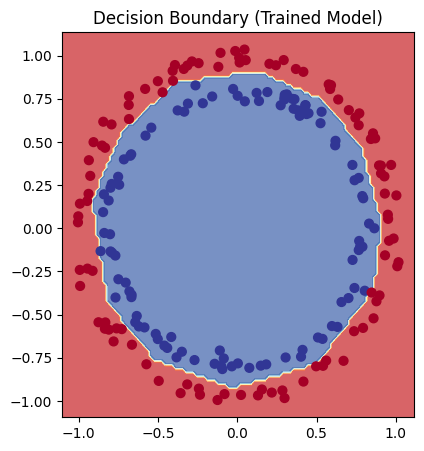

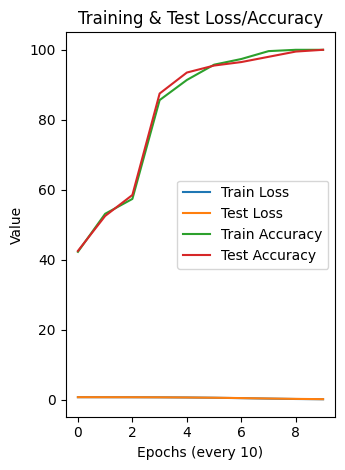

In [8]:
# 8. Plot decision boundary, loss, and accuracy

# Helper function to plot decision boundary (requires matplotlib and numpy)
def plot_decision_boundary(model, X, y):
    # Put everything to CPU (needed for NumPy conversion)
    X, y = X.cpu(), y.cpu()

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = torch.meshgrid(torch.linspace(x_min, x_max, 100),
                            torch.linspace(y_min, y_max, 100))

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_pred = torch.round(torch.sigmoid(model(torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)).squeeze()))

    y_pred = y_pred.reshape(xx.shape)

    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Decision Boundary (Trained Model)")
plot_decision_boundary(model_0, X_test, y_test)

plt.subplot(1, 2, 2)
plt.title("Training & Test Loss/Accuracy")
plt.plot(train_loss_list, label="Train Loss")
plt.plot(test_loss_list, label="Test Loss")
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(test_acc_list, label="Test Accuracy")
plt.xlabel("Epochs (every 10)")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()